In [1]:
from torchvision import models, transforms
from torch import nn, optim
import torch
from torch.utils.data import DataLoader, Dataset

# 加载预训练的 EfficientNet 或 ResNet
model = models.efficientnet_b0(pretrained=True)
# 替换分类头为二分类
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# 冻结特征提取层
for param in model.features.parameters():
    param.requires_grad = False

# 优化器和损失函数
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


/data1/humw/anaconda3/envs/photomaker/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data1/humw/anaconda3/envs/photomaker/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
# model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 图像输入大小，EfficientNet-B0 默认输入尺寸为 224x224
image_size = 224

# 定义训练集的数据增强和验证集的数据预处理
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet 均值
                         [0.229, 0.224, 0.225])   # ImageNet 方差
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset_path = "/data1/humw/Codes/My-Anti-DreamBooth/data/perturbed_images_dataset_v5"
# 数据集路径
train_dataset = datasets.ImageFolder(dataset_path + '/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(dataset_path + '/val', transform=val_transforms)

# 数据加载器
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)


Validation Loss: 0.3748, Accuracy: 0.8625
Epoch [1/5], Train Loss: 0.3142, Train Acc: 0.8831
Validation Loss: 0.3654, Accuracy: 0.8675
Epoch [2/5], Train Loss: 0.3074, Train Acc: 0.8869
Validation Loss: 0.3593, Accuracy: 0.8775
Epoch [3/5], Train Loss: 0.3129, Train Acc: 0.8788
Validation Loss: 0.3548, Accuracy: 0.8875
Epoch [4/5], Train Loss: 0.3072, Train Acc: 0.8769
Validation Loss: 0.3460, Accuracy: 0.8900
Epoch [5/5], Train Loss: 0.3008, Train Acc: 0.8856


/tmp/ipykernel_2285593/2146171002.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(epochs, train_losses, 'o-', label='Train Loss', color='black', marker='o', linestyle='-')
/tmp/ipykernel_2285593/2146171002.py:57: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(epochs, train_losses, 'o-', label='Train Loss', color='black', marker='o', linestyle='-')
/tmp/ipykernel_2285593/2146171002.py:58: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot(epochs, val_losses, 's--', label='Val Loss', color='green', marker='s', linestyle='--')
/tmp/ipykernel_2285593/2146171002.py:58: UserWarning: marker is redundantly 

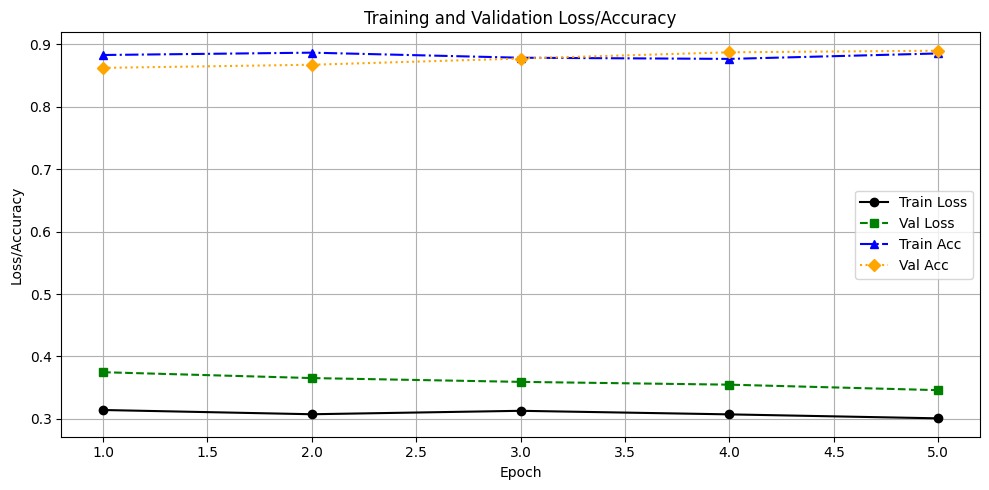

Validation Loss: 0.3460, Accuracy: 0.8900


In [6]:
import matplotlib.pyplot as plt

def test_model(model, val_loader, criterion):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    print(f'Validation Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        # 每轮在验证集上测试
        val_loss, val_acc = test_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}')
    # 绘制曲线并保存，使用不同线型和标记，便于黑白打印和视觉障碍人群区分
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10,5))
    plt.plot(epochs, train_losses, 'o-', label='Train Loss', color='black', marker='o', linestyle='-')
    plt.plot(epochs, val_losses, 's--', label='Val Loss', color='green', marker='s', linestyle='--')
    plt.plot(epochs, train_accs, '^-.', label='Train Acc', color='blue', marker='^', linestyle='-.')
    plt.plot(epochs, val_accs, 'D:', label='Val Acc', color='orange', marker='D', linestyle=':')
    plt.xlabel('Epoch')
    plt.ylabel('Loss/Accuracy')
    plt.title('Training and Validation Loss/Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('./train_val_curve.png')  # 保存到当前路径
    plt.show()
    return train_losses, train_accs, val_losses, val_accs

# 用法示例
train_losses, train_accs, val_losses, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)
val_loss, val_acc = test_model(model, val_loader, criterion)

In [7]:
train_accs = [6.681249999999999689e-01,7.668749999999999734e-01,7.974999999999999867e-01,8.012500000000000178e-01,8.268750000000000266e-01,8.425000000000000266e-01,8.481250000000000178e-01,8.475000000000000311e-01,8.499999999999999778e-01,8.649999999999999911e-01,8.537500000000000089e-01,8.606249999999999734e-01,8.612499999999999600e-01,8.649999999999999911e-01,8.718749999999999556e-01,8.718749999999999556e-01,8.712499999999999689e-01,8.750000000000000000e-01,8.762499999999999734e-01,8.812499999999999778e-01,8.662499999999999645e-01,8.787500000000000311e-01,8.918749999999999734e-01,8.824999999999999512e-01,8.850000000000000089e-01,8.931249999999999467e-01,8.862499999999999822e-01,8.943750000000000311e-01,8.818749999999999645e-01,8.787500000000000311e-01,8.837500000000000355e-01,8.993750000000000355e-01,9.018749999999999822e-01,8.912499999999999867e-01,9.062500000000000000e-01,8.906250000000000000e-01,9.043750000000000400e-01,8.993750000000000355e-01,8.912499999999999867e-01,8.962499999999999911e-01,8.987500000000000488e-01,8.887500000000000400e-01,8.937500000000000444e-01,9.037500000000000533e-01,9.106250000000000178e-01,9.081249999999999600e-01,9.100000000000000311e-01,9.143750000000000488e-01,9.174999999999999822e-01,9.118749999999999911e-01,8.950000000000000178e-01,9.087499999999999467e-01,8.993750000000000355e-01,9.043750000000000400e-01,9.031249999999999556e-01,9.162500000000000089e-01,8.968749999999999778e-01,9.037500000000000533e-01,9.124999999999999778e-01,9.137499999999999512e-01,9.118749999999999911e-01,9.124999999999999778e-01,9.118749999999999911e-01,9.187499999999999556e-01,9.143750000000000488e-01,9.093750000000000444e-01,9.031249999999999556e-01,9.231249999999999734e-01,8.993750000000000355e-01,9.124999999999999778e-01,9.150000000000000355e-01,9.037500000000000533e-01,9.043750000000000400e-01,9.156250000000000222e-01,9.162500000000000089e-01,9.162500000000000089e-01,9.131249999999999645e-01,9.231249999999999734e-01,9.156250000000000222e-01,9.143750000000000488e-01,9.018749999999999822e-01,9.168749999999999956e-01,9.062500000000000000e-01,9.150000000000000355e-01,9.274999999999999911e-01,9.224999999999999867e-01,9.168749999999999956e-01,9.243749999999999467e-01,9.218750000000000000e-01,9.168749999999999956e-01,9.200000000000000400e-01,9.037500000000000533e-01,9.224999999999999867e-01,9.137499999999999512e-01,9.193750000000000533e-01,9.112500000000000044e-01,9.018749999999999822e-01,9.231249999999999734e-01,9.137499999999999512e-01,9.187499999999999556e-01,9.124999999999999778e-01,9.224999999999999867e-01,9.200000000000000400e-01,9.243749999999999467e-01,9.168749999999999956e-01,9.318750000000000089e-01,9.193750000000000533e-01,9.137499999999999512e-01,9.156250000000000222e-01,9.068749999999999867e-01,9.256250000000000311e-01,9.093750000000000444e-01,9.250000000000000444e-01,9.206250000000000266e-01,9.224999999999999867e-01,9.274999999999999911e-01,9.237499999999999600e-01,9.274999999999999911e-01,9.174999999999999822e-01,9.218750000000000000e-01,9.156250000000000222e-01,9.181249999999999689e-01,9.237499999999999600e-01,9.218750000000000000e-01,9.243749999999999467e-01,9.200000000000000400e-01,9.162500000000000089e-01,9.237499999999999600e-01,9.181249999999999689e-01,9.181249999999999689e-01,9.206250000000000266e-01,9.293749999999999512e-01,9.106250000000000178e-01,9.181249999999999689e-01,9.256250000000000311e-01,9.256250000000000311e-01,9.243749999999999467e-01,9.218750000000000000e-01,9.250000000000000444e-01,9.137499999999999512e-01,9.193750000000000533e-01,9.106250000000000178e-01,9.287499999999999645e-01,9.231249999999999734e-01,9.274999999999999911e-01,9.112500000000000044e-01,9.231249999999999734e-01,9.262500000000000178e-01,9.262500000000000178e-01,9.212500000000000133e-01,9.306250000000000355e-01,9.212500000000000133e-01,9.337499999999999689e-01,9.231249999999999734e-01,9.250000000000000444e-01,9.343749999999999556e-01,9.387499999999999734e-01,9.331249999999999822e-01,9.256250000000000311e-01,9.200000000000000400e-01,9.243749999999999467e-01,9.262500000000000178e-01,9.124999999999999778e-01,9.137499999999999512e-01,9.187499999999999556e-01,9.231249999999999734e-01,9.243749999999999467e-01,9.312500000000000222e-01,9.162500000000000089e-01,9.262500000000000178e-01,9.293749999999999512e-01,9.237499999999999600e-01,9.281249999999999778e-01,9.218750000000000000e-01,9.237499999999999600e-01,9.162500000000000089e-01,9.187499999999999556e-01,9.300000000000000488e-01,9.187499999999999556e-01,9.231249999999999734e-01,9.256250000000000311e-01,9.243749999999999467e-01,9.293749999999999512e-01,9.212500000000000133e-01,9.268750000000000044e-01,9.318750000000000089e-01,9.237499999999999600e-01,9.250000000000000444e-01,9.224999999999999867e-01,9.256250000000000311e-01,9.237499999999999600e-01,9.331249999999999822e-01,9.156250000000000222e-01,9.212500000000000133e-01,9.231249999999999734e-01,9.300000000000000488e-01,9.293749999999999512e-01,9.231249999999999734e-01,9.293749999999999512e-01,9.231249999999999734e-01,9.306250000000000355e-01,9.356250000000000400e-01,9.368750000000000133e-01,9.187499999999999556e-01,9.200000000000000400e-01,9.181249999999999689e-01,9.300000000000000488e-01,9.362500000000000266e-01,9.224999999999999867e-01,9.343749999999999556e-01,9.281249999999999778e-01,9.362500000000000266e-01,9.387499999999999734e-01,9.224999999999999867e-01,9.306250000000000355e-01,9.250000000000000444e-01,9.418750000000000178e-01,9.218750000000000000e-01,9.262500000000000178e-01,9.274999999999999911e-01,9.306250000000000355e-01,9.343749999999999556e-01,9.231249999999999734e-01,9.056250000000000133e-01,9.293749999999999512e-01,9.350000000000000533e-01,9.231249999999999734e-01,9.193750000000000533e-01,9.250000000000000444e-01,9.306250000000000355e-01,9.231249999999999734e-01,9.243749999999999467e-01,9.287499999999999645e-01,9.387499999999999734e-01,9.306250000000000355e-01,9.337499999999999689e-01,9.312500000000000222e-01,9.293749999999999512e-01,9.300000000000000488e-01,9.399999999999999467e-01,9.268750000000000044e-01,9.243749999999999467e-01,9.243749999999999467e-01,9.143750000000000488e-01,9.393749999999999600e-01,9.218750000000000000e-01,9.168749999999999956e-01,9.212500000000000133e-01,9.324999999999999956e-01,9.324999999999999956e-01,9.212500000000000133e-01,9.350000000000000533e-01,9.300000000000000488e-01,9.281249999999999778e-01,9.337499999999999689e-01,9.262500000000000178e-01,9.218750000000000000e-01,9.306250000000000355e-01,9.212500000000000133e-01,9.356250000000000400e-01,9.131249999999999645e-01,9.362500000000000266e-01,9.256250000000000311e-01,9.287499999999999645e-01,9.318750000000000089e-01,9.224999999999999867e-01,9.224999999999999867e-01,9.256250000000000311e-01,9.300000000000000488e-01,9.231249999999999734e-01,9.274999999999999911e-01,9.218750000000000000e-01,9.350000000000000533e-01,9.312500000000000222e-01,9.300000000000000488e-01,9.324999999999999956e-01,9.375000000000000000e-01,9.312500000000000222e-01,9.350000000000000533e-01,9.312500000000000222e-01,9.281249999999999778e-01,9.193750000000000533e-01,9.312500000000000222e-01,9.281249999999999778e-01,9.218750000000000000e-01,9.343749999999999556e-01,9.181249999999999689e-01,9.287499999999999645e-01,9.350000000000000533e-01,9.243749999999999467e-01,9.337499999999999689e-01,9.256250000000000311e-01,9.287499999999999645e-01,9.324999999999999956e-01,9.368750000000000133e-01,9.425000000000000044e-01,9.293749999999999512e-01,9.425000000000000044e-01,9.256250000000000311e-01,9.393749999999999600e-01,9.318750000000000089e-01,9.331249999999999822e-01,9.318750000000000089e-01,9.287499999999999645e-01,9.181249999999999689e-01,9.243749999999999467e-01,9.381249999999999867e-01,9.362500000000000266e-01,9.268750000000000044e-01,9.231249999999999734e-01,9.218750000000000000e-01,9.337499999999999689e-01,9.281249999999999778e-01,9.306250000000000355e-01,9.318750000000000089e-01,9.368750000000000133e-01,9.112500000000000044e-01,9.287499999999999645e-01,9.181249999999999689e-01,9.243749999999999467e-01,9.406250000000000444e-01,9.368750000000000133e-01,9.262500000000000178e-01,9.324999999999999956e-01,9.387499999999999734e-01,9.300000000000000488e-01,9.287499999999999645e-01,9.237499999999999600e-01,9.287499999999999645e-01,9.212500000000000133e-01,9.250000000000000444e-01,9.256250000000000311e-01,9.237499999999999600e-01,9.287499999999999645e-01,9.331249999999999822e-01,9.324999999999999956e-01,9.393749999999999600e-01,9.318750000000000089e-01,9.337499999999999689e-01,9.356250000000000400e-01,9.362500000000000266e-01,9.306250000000000355e-01,9.256250000000000311e-01,9.300000000000000488e-01,9.274999999999999911e-01,9.293749999999999512e-01,9.293749999999999512e-01,9.231249999999999734e-01,9.268750000000000044e-01,9.268750000000000044e-01,9.356250000000000400e-01,9.337499999999999689e-01,9.281249999999999778e-01,9.324999999999999956e-01,9.268750000000000044e-01,9.262500000000000178e-01,9.375000000000000000e-01,9.281249999999999778e-01,9.287499999999999645e-01,9.256250000000000311e-01,9.262500000000000178e-01,9.368750000000000133e-01,9.356250000000000400e-01,9.256250000000000311e-01,9.312500000000000222e-01,9.206250000000000266e-01,9.362500000000000266e-01,9.224999999999999867e-01,9.231249999999999734e-01,9.212500000000000133e-01,9.268750000000000044e-01,9.318750000000000089e-01,9.324999999999999956e-01,9.306250000000000355e-01,9.281249999999999778e-01,9.318750000000000089e-01,9.287499999999999645e-01,9.281249999999999778e-01,9.293749999999999512e-01,9.287499999999999645e-01,9.287499999999999645e-01,9.418750000000000178e-01,9.312500000000000222e-01,9.375000000000000000e-01,9.206250000000000266e-01,9.287499999999999645e-01,9.250000000000000444e-01,9.300000000000000488e-01,9.287499999999999645e-01,9.250000000000000444e-01,9.281249999999999778e-01,9.293749999999999512e-01,9.300000000000000488e-01,9.250000000000000444e-01,9.306250000000000355e-01,9.362500000000000266e-01,9.387499999999999734e-01,9.306250000000000355e-01,9.375000000000000000e-01,9.293749999999999512e-01,9.237499999999999600e-01,9.200000000000000400e-01,9.268750000000000044e-01,9.306250000000000355e-01,9.375000000000000000e-01,9.337499999999999689e-01,9.343749999999999556e-01,9.318750000000000089e-01,9.331249999999999822e-01,9.350000000000000533e-01,9.449999999999999512e-01,9.362500000000000266e-01,9.287499999999999645e-01,9.356250000000000400e-01,9.243749999999999467e-01,9.224999999999999867e-01,9.318750000000000089e-01,9.287499999999999645e-01,9.324999999999999956e-01,9.449999999999999512e-01,9.300000000000000488e-01,9.312500000000000222e-01,9.425000000000000044e-01,9.300000000000000488e-01,9.399999999999999467e-01,9.312500000000000222e-01,9.243749999999999467e-01,9.368750000000000133e-01,9.331249999999999822e-01,9.362500000000000266e-01,9.331249999999999822e-01,9.312500000000000222e-01,9.318750000000000089e-01,9.300000000000000488e-01,9.268750000000000044e-01,9.250000000000000444e-01,9.237499999999999600e-01,9.300000000000000488e-01,9.268750000000000044e-01,9.331249999999999822e-01,9.262500000000000178e-01,9.212500000000000133e-01,9.250000000000000444e-01,9.193750000000000533e-01,9.243749999999999467e-01,9.212500000000000133e-01,9.362500000000000266e-01,9.143750000000000488e-01,9.331249999999999822e-01,9.393749999999999600e-01,9.243749999999999467e-01,9.231249999999999734e-01,9.343749999999999556e-01,9.375000000000000000e-01,9.387499999999999734e-01,9.368750000000000133e-01,9.337499999999999689e-01,9.437499999999999778e-01,9.350000000000000533e-01,9.300000000000000488e-01,9.350000000000000533e-01,9.375000000000000000e-01,9.318750000000000089e-01,9.287499999999999645e-01,9.287499999999999645e-01,9.262500000000000178e-01,9.287499999999999645e-01,9.318750000000000089e-01,9.237499999999999600e-01,9.293749999999999512e-01,9.393749999999999600e-01,9.143750000000000488e-01,9.224999999999999867e-01,9.318750000000000089e-01,9.312500000000000222e-01,9.306250000000000355e-01,9.181249999999999689e-01,9.381249999999999867e-01,9.281249999999999778e-01,9.281249999999999778e-01,9.268750000000000044e-01,9.324999999999999956e-01,9.306250000000000355e-01,9.350000000000000533e-01,9.274999999999999911e-01,9.250000000000000444e-01,9.312500000000000222e-01,9.381249999999999867e-01,9.293749999999999512e-01,9.312500000000000222e-01,9.324999999999999956e-01,9.375000000000000000e-01,9.293749999999999512e-01,9.324999999999999956e-01,9.243749999999999467e-01,9.337499999999999689e-01,9.250000000000000444e-01,9.406250000000000444e-01,9.318750000000000089e-01,9.300000000000000488e-01]
val_accs = [6.099999999999999867e-01,7.049999999999999600e-01,7.425000000000000488e-01,7.600000000000000089e-01,7.750000000000000222e-01,7.950000000000000400e-01,7.950000000000000400e-01,8.050000000000000488e-01,8.074999999999999956e-01,8.100000000000000533e-01,8.325000000000000178e-01,8.325000000000000178e-01,8.325000000000000178e-01,8.399999999999999689e-01,8.325000000000000178e-01,8.549999999999999822e-01,8.399999999999999689e-01,8.449999999999999734e-01,8.449999999999999734e-01,8.525000000000000355e-01,8.599999999999999867e-01,8.499999999999999778e-01,8.599999999999999867e-01,8.575000000000000400e-01,8.824999999999999512e-01,8.575000000000000400e-01,8.750000000000000000e-01,8.800000000000000044e-01,8.850000000000000089e-01,8.800000000000000044e-01,8.924999999999999600e-01,8.850000000000000089e-01,8.850000000000000089e-01,8.950000000000000178e-01,8.950000000000000178e-01,9.024999999999999689e-01,9.050000000000000266e-01,8.874999999999999556e-01,9.000000000000000222e-01,8.900000000000000133e-01,9.024999999999999689e-01,9.000000000000000222e-01,9.000000000000000222e-01,8.950000000000000178e-01,9.050000000000000266e-01,9.000000000000000222e-01,9.224999999999999867e-01,9.050000000000000266e-01,9.074999999999999734e-01,9.100000000000000311e-01,9.150000000000000355e-01,9.000000000000000222e-01,9.024999999999999689e-01,9.224999999999999867e-01,9.224999999999999867e-01,9.224999999999999867e-01,9.250000000000000444e-01,9.174999999999999822e-01,9.250000000000000444e-01,9.200000000000000400e-01,9.350000000000000533e-01,9.274999999999999911e-01,9.300000000000000488e-01,9.174999999999999822e-01,9.174999999999999822e-01,9.274999999999999911e-01,9.274999999999999911e-01,9.074999999999999734e-01,9.274999999999999911e-01,9.200000000000000400e-01,9.250000000000000444e-01,9.375000000000000000e-01,9.350000000000000533e-01,9.250000000000000444e-01,9.324999999999999956e-01,9.300000000000000488e-01,9.300000000000000488e-01,9.250000000000000444e-01,9.250000000000000444e-01,9.250000000000000444e-01,9.200000000000000400e-01,9.324999999999999956e-01,9.399999999999999467e-01,9.250000000000000444e-01,9.300000000000000488e-01,9.224999999999999867e-01,9.324999999999999956e-01,9.274999999999999911e-01,9.250000000000000444e-01,9.224999999999999867e-01,9.300000000000000488e-01,9.224999999999999867e-01,9.174999999999999822e-01,9.324999999999999956e-01,9.224999999999999867e-01,9.250000000000000444e-01,9.274999999999999911e-01,9.399999999999999467e-01,9.350000000000000533e-01,9.174999999999999822e-01,9.274999999999999911e-01,9.274999999999999911e-01,9.375000000000000000e-01,9.324999999999999956e-01,9.274999999999999911e-01,9.274999999999999911e-01,9.324999999999999956e-01,9.300000000000000488e-01,9.324999999999999956e-01,9.324999999999999956e-01,9.399999999999999467e-01,9.200000000000000400e-01,9.300000000000000488e-01,9.274999999999999911e-01,9.324999999999999956e-01,9.274999999999999911e-01,9.250000000000000444e-01,9.274999999999999911e-01,9.300000000000000488e-01,9.274999999999999911e-01,9.300000000000000488e-01,9.324999999999999956e-01,9.200000000000000400e-01,9.274999999999999911e-01,9.300000000000000488e-01,9.350000000000000533e-01,9.324999999999999956e-01,9.425000000000000044e-01,9.250000000000000444e-01,9.399999999999999467e-01,9.274999999999999911e-01,9.300000000000000488e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.274999999999999911e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.350000000000000533e-01,9.350000000000000533e-01,9.324999999999999956e-01,9.475000000000000089e-01,9.324999999999999956e-01,9.425000000000000044e-01,9.324999999999999956e-01,9.350000000000000533e-01,9.375000000000000000e-01,9.324999999999999956e-01,9.350000000000000533e-01,9.300000000000000488e-01,9.350000000000000533e-01,9.350000000000000533e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.274999999999999911e-01,9.375000000000000000e-01,9.300000000000000488e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.350000000000000533e-01,9.475000000000000089e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.300000000000000488e-01,9.425000000000000044e-01,9.250000000000000444e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.324999999999999956e-01,9.375000000000000000e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.525000000000000133e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.350000000000000533e-01,9.425000000000000044e-01,9.350000000000000533e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.499999999999999556e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.324999999999999956e-01,9.499999999999999556e-01,9.449999999999999512e-01,9.525000000000000133e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.475000000000000089e-01,9.525000000000000133e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.350000000000000533e-01,9.549999999999999600e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.499999999999999556e-01,9.375000000000000000e-01,9.250000000000000444e-01,9.499999999999999556e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.324999999999999956e-01,9.425000000000000044e-01,9.525000000000000133e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.575000000000000178e-01,9.449999999999999512e-01,9.350000000000000533e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.324999999999999956e-01,9.525000000000000133e-01,9.399999999999999467e-01,9.525000000000000133e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.350000000000000533e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.274999999999999911e-01,9.499999999999999556e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.324999999999999956e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.300000000000000488e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.575000000000000178e-01,9.375000000000000000e-01,9.525000000000000133e-01,9.375000000000000000e-01,9.449999999999999512e-01,9.300000000000000488e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.250000000000000444e-01,9.499999999999999556e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.350000000000000533e-01,9.350000000000000533e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.375000000000000000e-01,9.375000000000000000e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.324999999999999956e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.525000000000000133e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.499999999999999556e-01,9.475000000000000089e-01,9.525000000000000133e-01,9.499999999999999556e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.350000000000000533e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.375000000000000000e-01,9.375000000000000000e-01,9.499999999999999556e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.324999999999999956e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.525000000000000133e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.525000000000000133e-01,9.475000000000000089e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.375000000000000000e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.499999999999999556e-01,9.549999999999999600e-01,9.475000000000000089e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.375000000000000000e-01,9.525000000000000133e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.475000000000000089e-01,9.575000000000000178e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.350000000000000533e-01,9.399999999999999467e-01,9.324999999999999956e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.399999999999999467e-01,9.549999999999999600e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.375000000000000000e-01,9.425000000000000044e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.425000000000000044e-01,9.449999999999999512e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.399999999999999467e-01,9.525000000000000133e-01,9.300000000000000488e-01,9.549999999999999600e-01,9.399999999999999467e-01,9.324999999999999956e-01,9.499999999999999556e-01,9.324999999999999956e-01,9.425000000000000044e-01,9.499999999999999556e-01,9.425000000000000044e-01,9.499999999999999556e-01,9.499999999999999556e-01,9.350000000000000533e-01,9.499999999999999556e-01,9.449999999999999512e-01,9.499999999999999556e-01,9.425000000000000044e-01,9.399999999999999467e-01,9.425000000000000044e-01,9.549999999999999600e-01,9.499999999999999556e-01,9.399999999999999467e-01,9.350000000000000533e-01,9.449999999999999512e-01,9.525000000000000133e-01,9.350000000000000533e-01,9.449999999999999512e-01,9.425000000000000044e-01,9.525000000000000133e-01,9.449999999999999512e-01,9.549999999999999600e-01,9.499999999999999556e-01,9.475000000000000089e-01,9.525000000000000133e-01,9.324999999999999956e-01,9.449999999999999512e-01,9.475000000000000089e-01,9.449999999999999512e-01]
print(len(train_accs))
print(len(val_accs))

500
500


In [8]:
print(max(val_accs))

0.9575


In [9]:
print(max(train_accs))

0.945


In [22]:
# 打印test_accs中大于0.95的索引和值
for i, acc in enumerate(val_accs):
    if acc > 0.95:
        print(f"Index: {i}, Value: {acc:.4f}")
        # 打印对应索引的train_accs值
        print(f"Train Acc: {train_accs[i]:.4f}")

Index: 188, Value: 0.9525
Train Acc: 0.9225
Index: 212, Value: 0.9525
Train Acc: 0.9387
Index: 231, Value: 0.9525
Train Acc: 0.9244
Index: 239, Value: 0.9550
Train Acc: 0.9400
Index: 258, Value: 0.9525
Train Acc: 0.9213
Index: 264, Value: 0.9575
Train Acc: 0.9319
Index: 275, Value: 0.9525
Train Acc: 0.9325
Index: 277, Value: 0.9525
Train Acc: 0.9313
Index: 301, Value: 0.9575
Train Acc: 0.9331
Index: 303, Value: 0.9525
Train Acc: 0.9287
Index: 336, Value: 0.9525
Train Acc: 0.9394
Index: 343, Value: 0.9525
Train Acc: 0.9300
Index: 380, Value: 0.9525
Train Acc: 0.9287
Index: 394, Value: 0.9525
Train Acc: 0.9306
Index: 413, Value: 0.9550
Train Acc: 0.9356
Index: 420, Value: 0.9525
Train Acc: 0.9300
Index: 431, Value: 0.9575
Train Acc: 0.9313
Index: 448, Value: 0.9550
Train Acc: 0.9331
Index: 462, Value: 0.9525
Train Acc: 0.9319
Index: 464, Value: 0.9550
Train Acc: 0.9287
Index: 481, Value: 0.9550
Train Acc: 0.9325
Index: 486, Value: 0.9525
Train Acc: 0.9313
Index: 490, Value: 0.9525
Train 

In [12]:
train_losses = [6.403055584430694669e-01,5.704720455408096580e-01,5.344597208499908270e-01,5.034361875057220548e-01,4.660822945833206221e-01,4.473936921358108720e-01,4.225483423471450561e-01,4.129296725988387817e-01,4.046719455718993941e-01,3.846697086095809959e-01,3.801288950443267867e-01,3.669782084226608232e-01,3.660286176204681219e-01,3.547328501939773782e-01,3.460029128193855552e-01,3.403420180082321056e-01,3.323051333427429199e-01,3.184115195274352939e-01,3.128433412313461059e-01,3.182064065337181225e-01,3.313324695825576871e-01,3.149522238969802990e-01,3.035487645864486939e-01,3.024907138943672136e-01,2.975210553407668934e-01,2.820444875955581687e-01,2.977365970611572377e-01,2.805808657407760642e-01,2.920307621359825023e-01,3.014056381583213873e-01,2.891452074050903098e-01,2.758452162146568520e-01,2.673068767786025979e-01,2.742061728239059692e-01,2.694043147563934260e-01,2.843977749347686990e-01,2.680111771821975797e-01,2.691757866740226990e-01,2.794827282428741233e-01,2.605636686086654774e-01,2.652826419472694153e-01,2.724864277243614352e-01,2.646959862112999162e-01,2.549268478155136131e-01,2.514470282196998863e-01,2.522739204764365972e-01,2.470084063708782307e-01,2.423472143709659576e-01,2.398737698793411144e-01,2.485977047681808549e-01,2.581164550781249734e-01,2.459668004512786943e-01,2.480141702294349770e-01,2.467081873118877333e-01,2.466092963516712255e-01,2.383557116985320912e-01,2.499215874075889632e-01,2.442315822839736805e-01,2.293421831727028015e-01,2.326642212271690380e-01,2.319741344451904386e-01,2.333468312025070157e-01,2.308598461747169428e-01,2.222560007870197363e-01,2.225595378875732389e-01,2.415981191396713301e-01,2.452974170446395874e-01,2.131734579801559393e-01,2.418252727389335610e-01,2.242250767350196794e-01,2.220189723372459345e-01,2.336199517548084303e-01,2.315783251821994793e-01,2.219291663169860873e-01,2.283878540992736739e-01,2.148429459333419667e-01,2.275534370541572593e-01,2.113408774137496837e-01,2.080305631458759241e-01,2.336609886586666074e-01,2.375060379505157526e-01,2.166688120365142800e-01,2.325415788590907973e-01,2.214182896912098020e-01,2.025587387382984106e-01,2.173473909497261047e-01,2.191136734187603130e-01,2.008733427524566628e-01,2.107830674946308269e-01,2.141305364668369404e-01,2.142926871776580922e-01,2.300983554124832187e-01,2.072920197248458996e-01,2.227456159889698029e-01,2.153736294806003482e-01,2.236744872480630753e-01,2.351247560977935691e-01,2.106259210407733784e-01,2.176751260459423021e-01,2.009077356755733512e-01,2.133663207292556818e-01,2.083859688043594449e-01,2.116075929999351457e-01,1.965597864240407888e-01,2.038633079826831784e-01,1.971851325035095248e-01,2.066414971649646881e-01,2.166691802442073933e-01,2.061579144001007002e-01,2.193008746206760451e-01,2.010965718328952823e-01,2.304583814740180925e-01,1.967692811787128404e-01,2.124537645280361042e-01,1.974657548964023623e-01,1.902522796392440707e-01,2.009330990165472119e-01,1.991823722422123022e-01,2.090526425838470370e-01,2.008197447657585066e-01,2.043673765659332342e-01,2.016709810495376509e-01,2.027024061977863445e-01,2.043756495416164387e-01,1.947148880362510603e-01,2.030227565765380937e-01,1.991514059901237366e-01,1.950221218168735615e-01,2.059494866430759408e-01,2.173726208508014734e-01,2.027835445106029588e-01,1.991788049042224895e-01,2.176019495725631803e-01,1.989887569844722703e-01,1.934753471612930265e-01,1.933371971547603596e-01,1.936004179716110107e-01,2.088810944557190075e-01,1.990315203368663854e-01,2.085923857986927143e-01,2.025863075256347789e-01,2.068810598552227042e-01,1.861108429729938507e-01,1.990440750122070279e-01,1.931973195075988858e-01,2.146117530763149150e-01,1.959053032100200598e-01,1.914790442585945218e-01,2.001036949455738123e-01,2.100002388656139474e-01,1.901245994865894406e-01,2.026713620126247284e-01,1.852628035843372212e-01,2.004368487000465493e-01,1.872747091948986087e-01,1.837544921040535073e-01,1.816840702295303422e-01,1.793526086956262477e-01,1.923732407391071375e-01,2.022367905080318384e-01,1.913540744781494218e-01,1.861655673384666476e-01,2.071496224403381325e-01,2.082921624183654841e-01,2.105624377727508545e-01,1.931807681918144282e-01,1.942316786944866258e-01,1.871427646279335000e-01,1.991153667867183730e-01,1.844227342307567519e-01,1.856125724315643433e-01,2.042403236031532232e-01,1.867077738046646063e-01,1.983373621106147844e-01,1.953538820892572470e-01,2.125597232580185014e-01,1.965485535562038477e-01,1.807339776307344548e-01,1.962658087909221749e-01,1.907067763805389282e-01,1.978350064158439503e-01,1.930082792043685824e-01,1.913036593794822660e-01,1.902792906761169300e-01,1.918649633973836810e-01,1.768166138231754281e-01,1.953274025022983529e-01,1.940256782621145315e-01,1.904965238273143846e-01,1.866107186675071694e-01,1.842960540950298320e-01,1.718139697611331951e-01,1.986127702891826718e-01,1.870641669631004367e-01,1.916469448804855313e-01,1.737747818976640712e-01,1.872715820372104767e-01,1.909842720627784596e-01,1.864639856666326645e-01,1.778687289357185342e-01,1.895607008039951191e-01,1.686337533593177673e-01,1.589120340347290050e-01,1.939280082285404216e-01,2.098491382598876853e-01,2.045490656793117479e-01,1.883809923380613260e-01,1.702195423841476318e-01,1.974685982614755586e-01,1.791223496198654230e-01,1.818632660806178969e-01,1.771848945319652591e-01,1.774776171147823267e-01,1.828091500699520200e-01,1.754416163265705153e-01,1.905535370111465510e-01,1.656490965187549513e-01,1.874766963720321533e-01,1.901403240859508570e-01,1.811563886702060588e-01,1.761184430122375577e-01,1.729731331765651803e-01,1.871348546445369687e-01,2.047172921895980824e-01,1.831066872179508143e-01,1.693598403036594424e-01,1.894351178407669145e-01,1.985778161883354209e-01,1.771377710998058297e-01,1.771383407711982771e-01,1.833804628252982960e-01,1.796435444056987685e-01,1.742578540742397430e-01,1.704353621602058277e-01,1.730940167605876934e-01,1.813834498822688990e-01,1.836577091366052572e-01,1.836307945847511225e-01,1.857978625595569644e-01,1.672196929901838269e-01,1.882834163308143571e-01,1.848425228893756933e-01,1.860952764749526922e-01,2.007308444380760115e-01,1.743018218874931302e-01,1.889890510588884409e-01,2.042317839711904615e-01,1.835012396425008685e-01,1.773007890954613752e-01,1.731829988211393279e-01,1.868934848904609813e-01,1.662009543180465732e-01,1.769976228475570734e-01,1.783862157166004048e-01,1.738401593267917544e-01,1.939290863275527910e-01,1.935778620094060765e-01,1.731728801131248441e-01,1.951111137866973766e-01,1.675304939597845044e-01,2.086665803194046043e-01,1.661008939146995655e-01,1.863251410424709431e-01,1.900931046903133470e-01,1.787232410907745317e-01,1.811798143386840754e-01,1.946192936599254741e-01,1.834363187849521737e-01,1.784529478847980410e-01,1.790200233459472712e-01,1.870305588096380367e-01,1.842312879860401043e-01,1.710293290019035406e-01,1.853312700986862183e-01,1.869625274837017070e-01,1.708255776762962475e-01,1.681439869105815776e-01,1.799254306405782822e-01,1.693542812019586674e-01,1.687857332080602568e-01,1.912942873686551970e-01,1.836677895486354961e-01,1.731518241763115029e-01,1.924320763349532948e-01,1.861086446791887228e-01,1.705279050767421756e-01,1.976853732764720928e-01,1.736187838017940466e-01,1.792575885355472687e-01,1.786094725131988636e-01,1.718520496785640728e-01,1.812891492247581393e-01,1.744702047854661819e-01,1.671963686496019397e-01,1.612517096102237812e-01,1.557047914713621251e-01,1.778359608352184373e-01,1.579215044528246015e-01,1.813731388002634004e-01,1.612305814027786277e-01,1.732171174883842535e-01,1.650963252782821633e-01,1.765940327197313420e-01,1.777435939013957966e-01,1.988432987034320920e-01,1.879221828281879558e-01,1.606603614985942785e-01,1.640900857746601105e-01,1.760288904607295868e-01,1.773924809694290283e-01,1.873935540765523933e-01,1.650856914371252038e-01,1.840901672840118408e-01,1.710659121721982978e-01,1.711060757189989123e-01,1.687582023441791534e-01,2.033891437947750180e-01,1.857450034469366185e-01,1.880792191624641452e-01,1.731503607332706418e-01,1.532228731364011776e-01,1.617153432965278692e-01,1.770959129929542408e-01,1.707729906588792701e-01,1.705584771931171473e-01,1.714536001533270015e-01,1.787131886184215590e-01,1.906471709907054946e-01,1.829358570277690998e-01,1.930365620553493589e-01,1.818532034009694986e-01,1.852548699826002121e-01,1.815738537162542299e-01,1.726240379363298549e-01,1.729577919840812605e-01,1.602892607450485118e-01,1.586742570251226392e-01,1.678739105165004686e-01,1.801008717715740226e-01,1.670797077566385236e-01,1.644955316931009381e-01,1.769611679017543682e-01,1.795444256067275923e-01,1.909681783616542783e-01,1.797820863127708446e-01,1.684316851198673359e-01,1.738606403395533684e-01,1.905466768145561152e-01,1.748862270265817698e-01,1.857772858440875918e-01,1.692344618588685901e-01,1.797990702092647497e-01,1.816600092500448294e-01,1.694299532473087233e-01,1.812551154196262448e-01,1.945310138165950720e-01,1.746478990465402670e-01,1.679367006570100795e-01,1.749123303592204914e-01,1.747133220732212111e-01,1.855487265437841538e-01,1.728583682328462545e-01,1.707703715562820523e-01,1.758649682998657260e-01,1.815467219054698877e-01,1.966285197436809518e-01,1.665771107375621785e-01,1.861129841208457869e-01,1.825704924017191033e-01,1.934519885480403822e-01,1.780928234755992934e-01,1.671164477616548516e-01,1.652499406039714680e-01,1.787383410334587031e-01,1.802473437786102362e-01,1.880691502988338371e-01,1.751390802860260110e-01,1.716051585227250931e-01,1.860194139927625612e-01,1.771576077491044954e-01,1.781755954027176014e-01,1.588729826360940900e-01,1.715625377744436353e-01,1.712512157112359990e-01,1.800398162752389897e-01,1.700045869499444973e-01,1.828568868339061626e-01,1.642712941765785140e-01,1.774833507090806950e-01,1.817881412059068613e-01,1.819891027361154601e-01,1.778288555890321643e-01,1.616023625433445077e-01,1.794724717736244091e-01,1.642890341579913982e-01,1.682597331702709309e-01,1.736283126473426863e-01,1.795082645863294579e-01,1.544907525926828284e-01,1.758591318130493242e-01,1.802373206615447976e-01,1.877670875191688460e-01,1.694307642430067096e-01,1.585293850302696150e-01,1.500909917056560405e-01,1.642568331211805288e-01,1.659060935676097970e-01,1.676411268860101833e-01,1.785680713504552708e-01,1.611817693710327071e-01,1.503153868764638967e-01,1.624698654562234945e-01,1.716849964857101452e-01,1.636275412887334690e-01,1.871063908934593178e-01,1.780624476075172435e-01,1.651582489907741647e-01,1.695965124666690693e-01,1.621806425601244050e-01,1.569802866131067287e-01,1.845236238837242027e-01,1.773302045464515697e-01,1.557161039113998391e-01,1.742137897759676035e-01,1.614168151468038659e-01,1.685142042487859648e-01,1.863981385529041301e-01,1.618474107980728272e-01,1.771184092760086093e-01,1.650354132056236212e-01,1.709826514124870300e-01,1.755594547092914626e-01,1.761608176678419180e-01,1.767804589867591758e-01,1.662931209057569581e-01,1.862375050783157404e-01,1.762277272343635570e-01,1.700001921504736002e-01,1.864391153305768878e-01,1.630668519437313002e-01,1.758946232497692053e-01,1.938362989574670681e-01,1.792371904104947955e-01,1.919785276055336054e-01,1.772077359259128515e-01,1.915445519983768330e-01,1.564703973382711444e-01,1.993428514897823411e-01,1.744085983186960120e-01,1.566824641823768571e-01,1.750392232835292772e-01,1.824504832178354130e-01,1.687628956139087810e-01,1.587134963274001997e-01,1.529473116248846187e-01,1.641042020171880611e-01,1.807544693350791876e-01,1.465243032574653492e-01,1.623607490956783250e-01,1.778924366086721554e-01,1.715204902365803641e-01,1.698206603527069036e-01,1.693687334656715504e-01,1.779624252021312636e-01,1.690760925412178040e-01,1.780366263538598892e-01,1.776532030850648813e-01,1.695335620641708341e-01,1.758781465888023254e-01,1.680929933488368999e-01,1.550890377908945017e-01,1.948192733526229736e-01,1.801820460706949345e-01,1.756542875617742583e-01,1.646324513107538245e-01,1.765996560454368702e-01,1.922816631942987353e-01,1.553588145971298295e-01,1.780272576212882929e-01,1.789266862720250983e-01,1.780550924688577563e-01,1.677156984061002609e-01,1.736573661863803908e-01,1.530336467921733778e-01,1.787710064649581931e-01,1.790748549625277575e-01,1.701688522845506701e-01,1.564251878112554450e-01,1.687601506710052490e-01,1.675202152132987954e-01,1.668631127476692122e-01,1.669595745205879334e-01,1.724749974161386423e-01,1.686124769598245643e-01,1.743401729315519344e-01,1.665192607790231816e-01,1.891283769905567069e-01,1.547343853861093410e-01,1.673960530385374956e-01,1.656992968171834835e-01]
val_losses = [6.650975275039673340e-01,6.260849571228027655e-01,5.999786865711211892e-01,5.690854179859161643e-01,5.569282829761504905e-01,5.235245323181152433e-01,5.112548661231994807e-01,5.015203094482422186e-01,4.887464499473571644e-01,4.737258279323577903e-01,4.574944913387298806e-01,4.505789875984191895e-01,4.453008067607879816e-01,4.328665471076965088e-01,4.304997777938842640e-01,4.119891142845154008e-01,4.098294115066528076e-01,4.036403495073318526e-01,3.954379779100418157e-01,3.911063432693481223e-01,3.766892302036285445e-01,3.813813608884811246e-01,3.734395766258239990e-01,3.683360105752944702e-01,3.616241645812988126e-01,3.734355515241623014e-01,3.524830585718154996e-01,3.469866389036178611e-01,3.445549261569976762e-01,3.483259695768356479e-01,3.361272764205932573e-01,3.316900831460952714e-01,3.298877167701721458e-01,3.259175062179565652e-01,3.187119680643081820e-01,3.179424512386321844e-01,3.149364072084426813e-01,3.193403428792953580e-01,3.122921854257583729e-01,3.127230918407440385e-01,3.082022720575332553e-01,3.091661965847015137e-01,3.057512342929840088e-01,3.041992408037185736e-01,3.004258501529693537e-01,3.004101556539535700e-01,2.891832971572875777e-01,2.926028650999069058e-01,2.919397622346878163e-01,2.968058675527572854e-01,2.864294180274009616e-01,2.916688546538352966e-01,2.814403343200683749e-01,2.776771581172943204e-01,2.695707505941390969e-01,2.799968856573105125e-01,2.684263408184051625e-01,2.763841003179550171e-01,2.688112425804138339e-01,2.784054952859878473e-01,2.676546859741211204e-01,2.674023386836051897e-01,2.639438900351524508e-01,2.699376776814460532e-01,2.708762413263320901e-01,2.551988866925239408e-01,2.549860012531280362e-01,2.684156852960586370e-01,2.587894791364669933e-01,2.647722655534744396e-01,2.551155006885528764e-01,2.430153733491897672e-01,2.435318738222122248e-01,2.524272498488426275e-01,2.498175042867660511e-01,2.416230034828185935e-01,2.493649628758430603e-01,2.547812399268150063e-01,2.543886238336562911e-01,2.535228687524795355e-01,2.510033443570137135e-01,2.392200449109077587e-01,2.380364412069320701e-01,2.481279885768890303e-01,2.376483359932899386e-01,2.422531381249427851e-01,2.404688280820846680e-01,2.427818357944488414e-01,2.400131258368492226e-01,2.388639175891876243e-01,2.397492060065269381e-01,2.468276676535606506e-01,2.502581286430358709e-01,2.365346768498420849e-01,2.331104221940040466e-01,2.353202798962593101e-01,2.334996369481086853e-01,2.302960190176963906e-01,2.220635893940925698e-01,2.379248428344726551e-01,2.270528829097747670e-01,2.411418688297271851e-01,2.300538909435272117e-01,2.246827223896980252e-01,2.300669535994529780e-01,2.288432019948959395e-01,2.250889307260513228e-01,2.236356949806213301e-01,2.207027009129524098e-01,2.226822409033775430e-01,2.214737388491630488e-01,2.332583412528038136e-01,2.123255333304405190e-01,2.289669355750083846e-01,2.177257835865020752e-01,2.193968126177787692e-01,2.171991997957229692e-01,2.270255330204963562e-01,2.240416747331619163e-01,2.151019257307052734e-01,2.151894268393516607e-01,2.168901363015174888e-01,2.196608710289001398e-01,2.255870783329010087e-01,2.091117399930954024e-01,2.112769183516502447e-01,2.155701029300689797e-01,2.078445851802825928e-01,2.216998898983001676e-01,2.121482288837432950e-01,2.171989464759826738e-01,2.194124630093574613e-01,2.103439140319824097e-01,2.086297166347503562e-01,2.203150305151939381e-01,2.168392285704612843e-01,1.995396018028259277e-01,2.150217419862747170e-01,2.023520386219024580e-01,2.198442029953003030e-01,2.076690879464149486e-01,2.111993360519409113e-01,2.037469384074211132e-01,2.098321205377578769e-01,2.056371253728866699e-01,2.112751019001007091e-01,2.105477884411811884e-01,2.079552432894706815e-01,2.095525893568992715e-01,2.073501503467559681e-01,2.184360569715499967e-01,2.162655219435691833e-01,1.975710597634315613e-01,2.070659101009368896e-01,2.000749117136001454e-01,1.992815184593200728e-01,2.053706631064415034e-01,2.030747568607330356e-01,2.066834677755832739e-01,2.072370812296867315e-01,1.954921057820320218e-01,1.990276122093200817e-01,1.935542938113212486e-01,2.062063923478126559e-01,1.914515447616577104e-01,1.948695814609527621e-01,2.002323967218399003e-01,1.991789582371711609e-01,1.990932950377464206e-01,1.945472398400306668e-01,1.958841371536254872e-01,2.118241807818412870e-01,1.999259185791015525e-01,2.115114302933216173e-01,1.996871134638786294e-01,1.981687381863594111e-01,2.071132418513298157e-01,1.930033782124519481e-01,1.914371204376220659e-01,1.995066347718238708e-01,1.970763480663299538e-01,1.946956311166286591e-01,1.904346030950546387e-01,1.913585227727890026e-01,1.978198975324630682e-01,1.918384250998496909e-01,2.048461687564849809e-01,1.865626975893974193e-01,1.857246062159538247e-01,1.993471199274063077e-01,1.883988425135612599e-01,1.949841561913490395e-01,1.940183615684509255e-01,1.945127712190151126e-01,1.938293287158012468e-01,1.822592499852180581e-01,2.003397446870803789e-01,1.856153716146946020e-01,1.926728096604347351e-01,1.870991978049278137e-01,1.916819852590560813e-01,1.848629182577133101e-01,1.813701853156089727e-01,1.918841838836669866e-01,1.858189778029918637e-01,1.804684060811996560e-01,1.942253148555755649e-01,1.868036253750324227e-01,1.816497883200645369e-01,1.961375331878661976e-01,1.837994268536567721e-01,1.828917261958122320e-01,1.830543130636215210e-01,2.019222575426101729e-01,1.938004536926746235e-01,1.824006453156471197e-01,1.775076417624950331e-01,1.937129127979278498e-01,1.863469099998474043e-01,1.856498740613460596e-01,1.900942172110080819e-01,1.893327343463897805e-01,1.917448170483112280e-01,1.857440365850925312e-01,1.794092130661010809e-01,1.926232188940048273e-01,1.915658545494079712e-01,1.898289772868156366e-01,1.798148760199546892e-01,1.958784595131874140e-01,1.809299030900001493e-01,1.806835970282554549e-01,1.796279153227806069e-01,1.769076651334762496e-01,1.982630088925361744e-01,1.815525466203689597e-01,1.761551931500434931e-01,1.903440466523170504e-01,1.953680674731731459e-01,1.809413659572601252e-01,1.799448665976524364e-01,1.784219962358474798e-01,1.820217606425285350e-01,1.847662787139415785e-01,1.736106249690055892e-01,1.760975846648216159e-01,1.765310123562812694e-01,1.838363239169120700e-01,1.837468196451663982e-01,1.788112464547157165e-01,1.718197101354599077e-01,2.002665790915489075e-01,1.941903971135616191e-01,1.722788900136947576e-01,1.879270261526107821e-01,1.803621593117713806e-01,1.887440410256385759e-01,1.758702400326728754e-01,1.789878532290458679e-01,1.713462358713150058e-01,1.813124546408653170e-01,1.907020281255245309e-01,1.758500310778617903e-01,1.801650768518447965e-01,1.694187632203102145e-01,1.779643356800079401e-01,1.875611944496631545e-01,1.841528214514255579e-01,1.796511961519718092e-01,1.749951115250587552e-01,1.743964979052543551e-01,1.792288917303085372e-01,1.742434057593345575e-01,1.731858964264392786e-01,1.830510362982749883e-01,1.751763865351677052e-01,1.847579483687877555e-01,1.673057693243026611e-01,1.811890384554862843e-01,1.818292680382728455e-01,1.860501918196678095e-01,1.746531867980957164e-01,1.830863358080387082e-01,1.789102867245674078e-01,1.764478112757205952e-01,1.742016288638114918e-01,1.962023220956325420e-01,1.734055593609809820e-01,1.800859257578849848e-01,1.663133330643176977e-01,1.830910003185272084e-01,1.878055022656917594e-01,1.600933927297592263e-01,1.816487398743629467e-01,1.839679566025733959e-01,1.713707250356674150e-01,1.710217906534671761e-01,1.704129947721958194e-01,1.671363045275211234e-01,1.688127380609512340e-01,1.723882412910461293e-01,1.583714683353900921e-01,1.898414674401283364e-01,1.671086680889129761e-01,1.716375532746315102e-01,1.606850594282150380e-01,1.877116413414478269e-01,1.637643091380596161e-01,1.768549525737762584e-01,1.757031829655170407e-01,1.727983941137790636e-01,1.742011353373527638e-01,1.940214546024799369e-01,1.737369154393672843e-01,1.673119257390499048e-01,1.727464090287685328e-01,1.739477382600307376e-01,1.810531321167945795e-01,1.621143361926078719e-01,1.775479221343994052e-01,1.688254566490650088e-01,1.664471188187599260e-01,1.727631253004074108e-01,1.722403833270073070e-01,1.752781763672828785e-01,1.768715772032737610e-01,1.728076653182506472e-01,1.789186680316925127e-01,1.699035988748073545e-01,1.712979875504970495e-01,1.665869347751140483e-01,1.626419080793857497e-01,1.708248399198055156e-01,1.807342407107353222e-01,1.796921724081039506e-01,1.784850424528121871e-01,1.693575070798397086e-01,1.683583961427211895e-01,1.688386516273021609e-01,1.618734970688819885e-01,1.649234476685524087e-01,1.646012850105762482e-01,1.723916384577751093e-01,1.638497200608253490e-01,1.684562775492668141e-01,1.649371489882469066e-01,1.619808848202228535e-01,1.682810284197330530e-01,1.649876219034195068e-01,1.629450178146362171e-01,1.681754428148269642e-01,1.683290654420852572e-01,1.627429255843162448e-01,1.795353278517723139e-01,1.725186441838741369e-01,1.691951511800289243e-01,1.625940370559692261e-01,1.789673621952533600e-01,1.701232613623142320e-01,1.539003455638885409e-01,1.647063508629798834e-01,1.661051630973816029e-01,1.627317659556865581e-01,1.687727087736129727e-01,1.696766333281993777e-01,1.621627220511436540e-01,1.719280873239040497e-01,1.726317070424556732e-01,1.683911496400833097e-01,1.650071252882480688e-01,1.637929370999336165e-01,1.602868121862411621e-01,1.723674808442592632e-01,1.644283051788806849e-01,1.776359641551971402e-01,1.588246640563011070e-01,1.666604749858379420e-01,1.598453961312770732e-01,1.695814251899719349e-01,1.773454689979553356e-01,1.538779258728027455e-01,1.674510328471660592e-01,1.588901208341121640e-01,1.626173824071884266e-01,1.665140396356582508e-01,1.661754757165908869e-01,1.757202294468879766e-01,1.692107753455638908e-01,1.665246927738189830e-01,1.608787663280963898e-01,1.639769279956817538e-01,1.611269456148147483e-01,1.660867395997047413e-01,1.692662018537521296e-01,1.575974166393279974e-01,1.585346101224422433e-01,1.596674895286560036e-01,1.586930398643016937e-01,1.677839444577693961e-01,1.579558929800987110e-01,1.648150061070919048e-01,1.580862596631050221e-01,1.561211666464805692e-01,1.626093026995658886e-01,1.688561147451400624e-01,1.725976912677288089e-01,1.614075717329978843e-01,1.638841056823730491e-01,1.553173828124999878e-01,1.627058549225330331e-01,1.659343628585338570e-01,1.731680747866630454e-01,1.523843580484390281e-01,1.529007223248481651e-01,1.632226198911666815e-01,1.697880396246910228e-01,1.648849791288375943e-01,1.526123629510402757e-01,1.598022449016570923e-01,1.698021394014358476e-01,1.509972459077835172e-01,1.543855300545692311e-01,1.634526915848255046e-01,1.608857777714729209e-01,1.604644486308097751e-01,1.611374443769454934e-01,1.684333807229995705e-01,1.541953910887241264e-01,1.654147316515445776e-01,1.602013671398162808e-01,1.557489857077598572e-01,1.514758330583572399e-01,1.580767318606376703e-01,1.712876915931701716e-01,1.650261333584785439e-01,1.618663828074932143e-01,1.573628124594688427e-01,1.553838154673576333e-01,1.658449009060859736e-01,1.641225942969322116e-01,1.630121375620365021e-01,1.820377138257026628e-01,1.699253700673580281e-01,1.712597873806953330e-01,1.612150512635707744e-01,1.664977243542671292e-01,1.657151222229003851e-01,1.664365606009960141e-01,1.548229250311851379e-01,1.579907426238059964e-01,1.633201859891414698e-01,1.617422060668468609e-01,1.577005356550216786e-01,1.587744274735450878e-01,1.595068892836570829e-01,1.636275838315486841e-01,1.621734791994094982e-01,1.677902099490165833e-01,1.529257009923458144e-01,1.603680112957954484e-01,1.574193280935287376e-01,1.667697416245937370e-01,1.533887672424316395e-01,1.786450102925300487e-01,1.555062863230705361e-01,1.635352668166160650e-01,1.745632500946521781e-01,1.492867848277091847e-01,1.771424813568591994e-01,1.697615711390972060e-01,1.548110066354274617e-01,1.609155549108982064e-01,1.539216977357864280e-01,1.537780947983264923e-01,1.815567654371261497e-01,1.514660631120204881e-01,1.554781752824783425e-01,1.541026057302951890e-01,1.628560982644557953e-01,1.648826719820499498e-01,1.646859577298164234e-01,1.596806687116622825e-01,1.551955993473529694e-01,1.585701663792133398e-01,1.731215456128120389e-01,1.607669587433338265e-01,1.465977115929126828e-01,1.614100098609924372e-01,1.541097474098205578e-01,1.499917216598987690e-01,1.549064351618290036e-01,1.550219492614269279e-01,1.444455899298190960e-01,1.553372633457183738e-01,1.575678804516792431e-01,1.508168935775756891e-01,1.722371774911880538e-01,1.597277340292930503e-01,1.581312528252601657e-01,1.562082175910472770e-01]
print(len(val_losses))
print(len(train_losses))

500
500


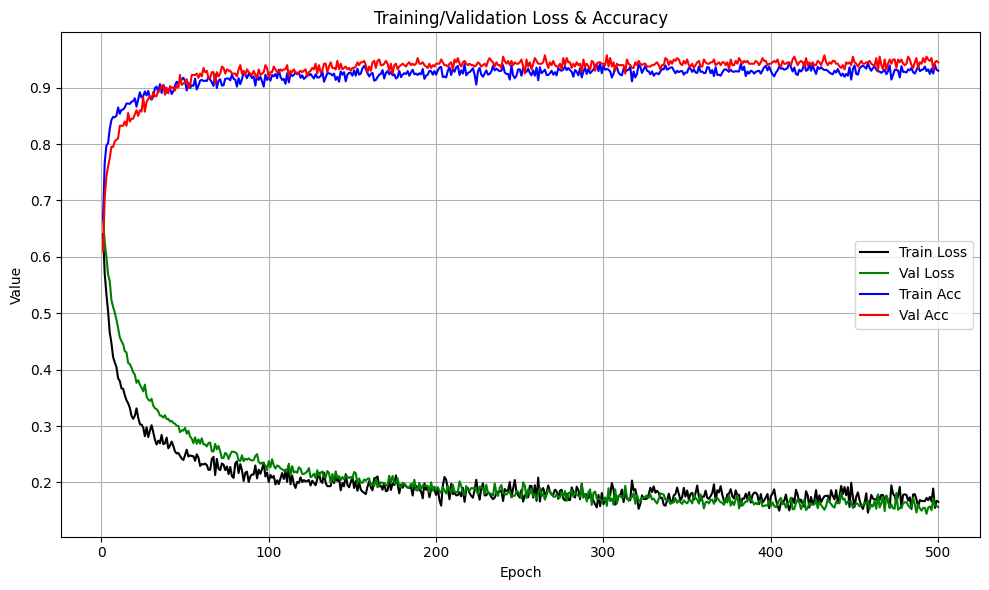

In [20]:
# 绘制train_accs, val_accs, train_losses, val_losses四个数组的折线图，绘制的点数不超过50
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    # 下采样，保证点数不超过50
    def downsample(arr, max_points=500):
        step = max(1, len(arr) // max_points)
        return arr[::step]
    train_losses_ds = downsample(train_losses)
    val_losses_ds = downsample(val_losses)
    train_accs_ds = downsample(train_accs)
    val_accs_ds = downsample(val_accs)
    epochs = range(1, len(train_losses_ds) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses_ds, color='black', label='Train Loss')
    plt.plot(epochs, val_losses_ds, color='green', label='Val Loss')
    plt.plot(epochs, train_accs_ds, color='blue', label='Train Acc')
    plt.plot(epochs, val_accs_ds, color='red', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training/Validation Loss & Accuracy')
    plt.legend()
    
# 调用
plot_metrics(train_losses, val_losses, train_accs, val_accs)

# 绘制图表并保存为图片
plt.grid(True)
plt.tight_layout()
plt.savefig('./train_val_curve.png')
plt.show()